# MLP-VQVAE training

# Using rotation trick

In [1]:
#Import custom classes and libraries
from src.Data.data_loading import ParquetDataModule
from src.Data.data_loading import ParquetFeatureDataset
from src.Models.VQ_VAE_MLP import VQVAE_MLP 

import yaml
import numpy as np
from tqdm import tqdm
import torch
import lightning as L
import matplotlib.pyplot as plt


#Open config file
with open("Configs/config.yaml") as f:
    config = yaml.safe_load(f)

#Extract config info
#Directories
dirs_train = config["data"]["train_path"]
dirs_val = config["data"]["val_path"]
dirs_test = config["data"]["test_path"]

#Features
features_cols = config["data"]["features"]
max_part = config["data"]["max_part"]
prep = config["data"]["preprocessing"]

#VQVAE hyperparameters
input_dim = config["MLP_VQVAE"]["input_dim"]
hidden_dim = config["MLP_VQVAE"]["hidden_dim"]
latent_dim = config["MLP_VQVAE"]["latent_dim"]
codebook_size = config["MLP_VQVAE"]["codebook_size"]
rot_trick = config["MLP_VQVAE"]["rotation_trick"]
decay = config["MLP_VQVAE"]["decay"]
beta = config["MLP_VQVAE"]["beta"]

#Training hyperparameters
lr = config["training"]["lr"]
max_epochs = config["training"]["max_epochs"]
batch_size = config["training"]["batch_size"]


#Initialization of itarable dataset (train dataset) containing the constituents' features (eta, phi, pT)
#In particular I am currently using the first 4 parquet files
dataset_train = ParquetFeatureDataset(
    parquet_dirs=dirs_train,
    features=features_cols,
    max_particles=max_part,
    batch_size=batch_size,
    preprocessing=prep
)

#Validation dataset
#In particular I am currently using parquet files n. 5,6
dataset_val = ParquetFeatureDataset(
    parquet_dirs=dirs_val,
    features=features_cols,
    max_particles=max_part,
    batch_size=batch_size,
    preprocessing=prep
)

#Test dataset
#In particular I am currently using parquet file n. 7
dataset_test = ParquetFeatureDataset(
    parquet_dirs=dirs_test,
    features=features_cols,
    max_particles=max_part,
    batch_size=batch_size,
    preprocessing=prep
)

#Initialization of the lightining datamodule (train)
data_module = ParquetDataModule(
    parquet_dirs_train=dirs_train, 
    parquet_dirs_val=dirs_val,
    parquet_dirs_test=dirs_test,
    features=features_cols,
    window_particles=max_part,
    batch_size=batch_size,
    preprocessing=prep
    #num_workers=0
)

In [2]:
#Model
model_with_rot = VQVAE_MLP(
    dec=decay,
    beta = beta,
    rot_trick=rot_trick,
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    codebook_size=codebook_size,
    lr=lr
)

#Trainer (Lightning)
trainer_with_rot = L.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",   #CPU/GPU automatic
    devices="auto",
    log_every_n_steps=10
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [3]:
#Train
trainer_with_rot.fit(model_with_rot, datamodule=data_module)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
2026-04-24 10:39:37.056392: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-24 10:39:37.187659: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-24 10:39:37.227861: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-24 10:39:37.424436: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in perfor

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ Encoder        │ 33.5 K │ train │     0 │
│ 1 │ decoder │ Decoder        │ 33.3 K │ train │     0 │
│ 2 │ vq      │ VectorQuantize │      0 │ train │     0 │
└───┴─────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 66.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 66.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/francesco/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/home/francesco/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=2` reached.


In [4]:
#Validation
trainer_with_rot.validate(model_with_rot, datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      val_commit_loss      │            0.0            │
│         val_loss          │    0.04368949308991432    │
│      val_recon_loss       │    0.04368949308991432    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.04368949308991432,
  'val_recon_loss': 0.04368949308991432,
  'val_commit_loss': 0.0}]

In [5]:
#Test 
trainer_with_rot.test(model_with_rot, datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/francesco/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test_commit_loss      │            0.0            │
│         test_loss         │   0.043579570949077606    │
│      test_recon_loss      │   0.043579570949077606    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.043579570949077606,
  'test_recon_loss': 0.043579570949077606,
  'test_commit_loss': 0.0}]

In [6]:
#For loading a model from a checkpoint
#model = VQVAE_MLP.load_from_checkpoint("lightning_logs/version_16/checkpoints/epoch=49-step=27150.ckpt")

### Codebook utilization

In [7]:
#Codebook utilization
codebook = []
model_with_rot.eval()

for batch, mask in dataset_test:
    
    with torch.no_grad():
        output = model_with_rot.forward(batch, mask)
    
    for element in output[2]:
        codebook.append(element.item())

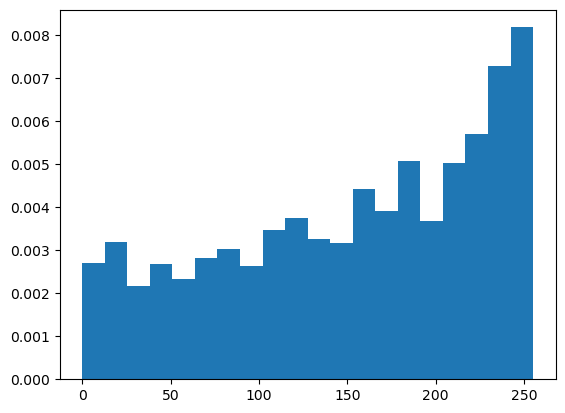

codebook utilization: 1.0


In [8]:
plt.hist(codebook, density=True, bins=20)
plt.show()

cb_util = list(set(codebook))
cb_util = len(cb_util) / 256
print(f'codebook utilization: {cb_util}')

### Reconstructed particle features

In [9]:
#Return the particles' features of all the events in a batch
def extract_features(x, mask):
    
    eta_list = []
    phi_list = []
    pT_list = []

    for i in range(x.shape[0]):
        valid = x[i][mask[i]]
        for eta, phi, pT in valid:
            eta_list.append(eta)
            phi_list.append(phi)
            pT_list.append(pT)
    
    return eta_list, phi_list, pT_list

In [10]:
#Create the reconstructed feature lists 
eta_list = []
phi_list = []
pT_list = []

model_with_rot.eval()

for batch, mask in dataset_test:
    with torch.no_grad():
        output = model_with_rot.forward(batch, mask)
    
    feat = extract_features(output[0], mask)
    for i in range(len(feat[0])):
        eta_list.append(feat[0][i])
        phi_list.append(feat[1][i])
        pT_list.append(feat[2][i])


In [11]:
#Create the original feature lists
   
eta_list_orig = []
phi_list_orig = []
pT_list_orig = []

for batch, mask in dataset_test:
    for i in range(batch.shape[0]):
        valid = batch[i][mask[i]]
        for eta, phi, pT in valid:
            eta_list_orig.append(eta)
            phi_list_orig.append(phi)
            pT_list_orig.append(pT)

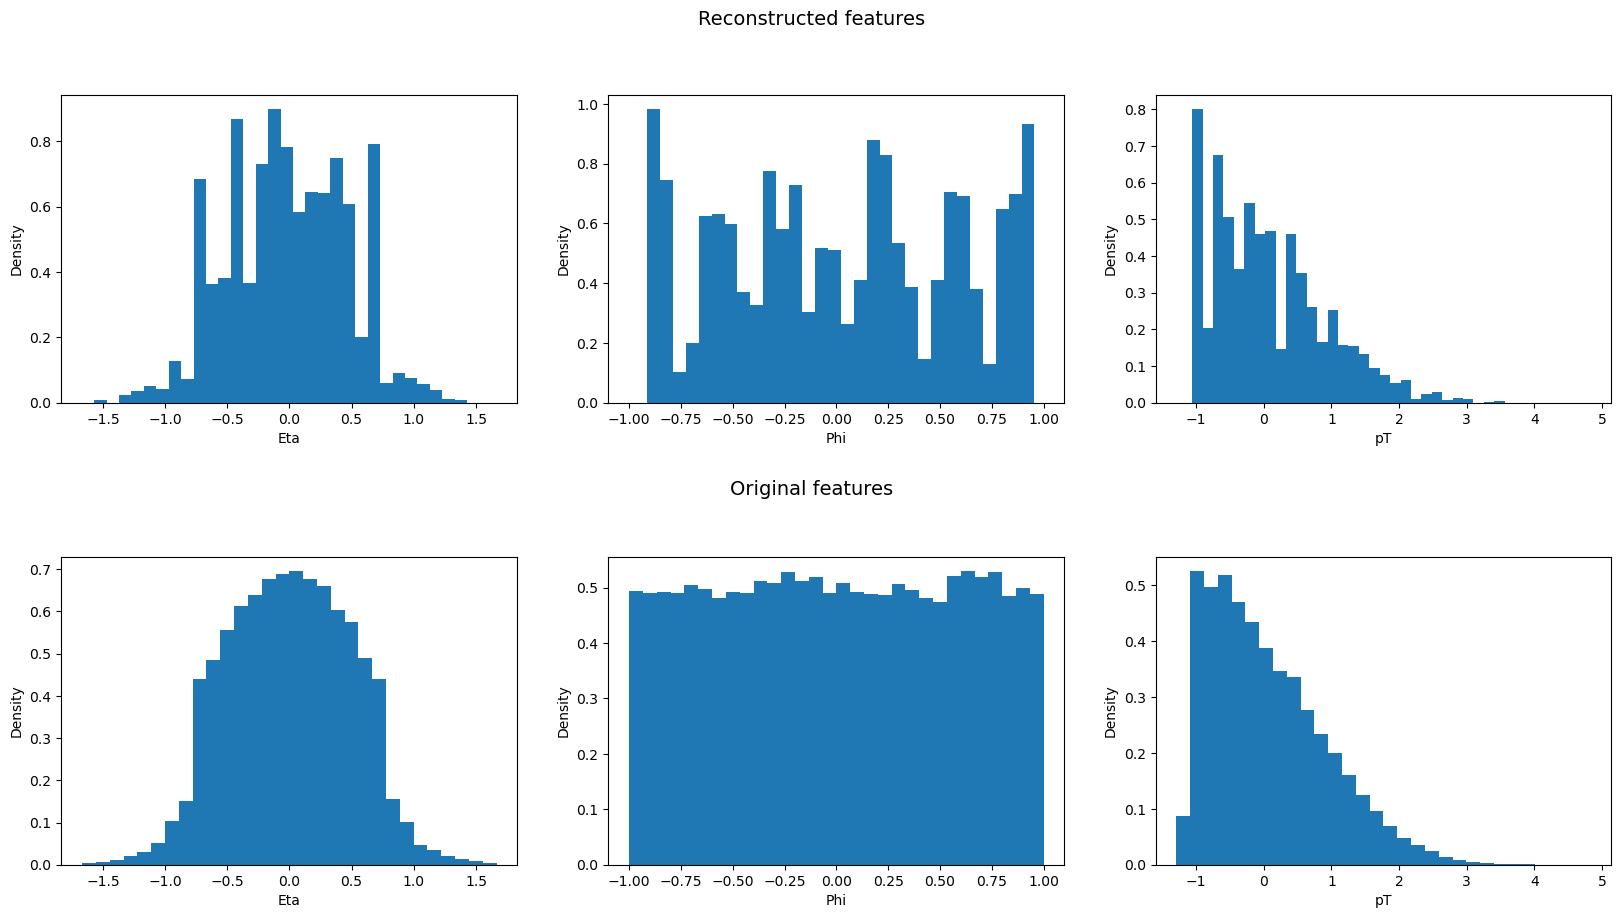

In [12]:
#Plot the reconstructed features and the original ones (preprocessed)
fig, ax = plt.subplots(2, 3, figsize=(20,10))

for i in range(3):
    ax[0, i].sharex(ax[1, i])

ax[0,0].hist(eta_list, density=True, bins=30)
ax[0,0].set_xlabel("Eta")
ax[0,0].set_ylabel("Density")

ax[0,1].hist(phi_list, density=True, bins=30)
ax[0,1].set_xlabel("Phi")
ax[0,1].set_ylabel("Density")

ax[0,2].hist(pT_list, density=True, bins=30)
ax[0,2].set_xlabel("pT")
ax[0,2].set_ylabel("Density")

fig.text(0.5, 0.95, "Reconstructed features", ha='center', fontsize=14)
fig.subplots_adjust(hspace=0.5)
fig.text(0.5, 0.48, "Original features", ha='center', fontsize=14)

ax[1,0].hist(eta_list_orig, density=True, bins=30)
ax[1,0].set_xlabel("Eta")
ax[1,0].set_ylabel("Density")

ax[1,1].hist(phi_list_orig, density=True, bins=30)
ax[1,1].set_xlabel("Phi")
ax[1,1].set_ylabel("Density")

ax[1,2].hist(pT_list_orig, density=True, bins=30)
ax[1,2].set_xlabel("pT")
ax[1,2].set_ylabel("Density")


plt.show()

## Without rotation trick

In [13]:
#Model
model_no_rot = VQVAE_MLP(
    dec=decay,
    beta = beta,
    rot_trick=False,
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    codebook_size=codebook_size,
    lr=lr
)

#Trainer (Lightning)
trainer_no_rot = L.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",   #CPU/GPU automatic
    devices="auto",
    log_every_n_steps=10
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [14]:
#Train
trainer_no_rot.fit(model_no_rot, datamodule=data_module)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ Encoder        │ 33.5 K │ train │     0 │
│ 1 │ decoder │ Decoder        │ 33.3 K │ train │     0 │
│ 2 │ vq      │ VectorQuantize │      0 │ train │     0 │
└───┴─────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 66.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 66.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=2` reached.


In [15]:
#Validation
trainer_no_rot.validate(model_no_rot, datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      val_commit_loss      │            0.0            │
│         val_loss          │    0.04531564563512802    │
│      val_recon_loss       │    0.04531564563512802    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.04531564563512802,
  'val_recon_loss': 0.04531564563512802,
  'val_commit_loss': 0.0}]

In [16]:
#Test 
trainer_no_rot.test(model_no_rot, datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test_commit_loss      │            0.0            │
│         test_loss         │    0.04517420381307602    │
│      test_recon_loss      │    0.04517420381307602    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.04517420381307602,
  'test_recon_loss': 0.04517420381307602,
  'test_commit_loss': 0.0}]

### Codebook utilization

In [17]:
#Codebook utilization
codebook = []
model_no_rot.eval()

for batch, mask in dataset_test:
    
    with torch.no_grad():
        output = model_no_rot.forward(batch, mask)
    
    for element in output[2]:
        codebook.append(element.item())

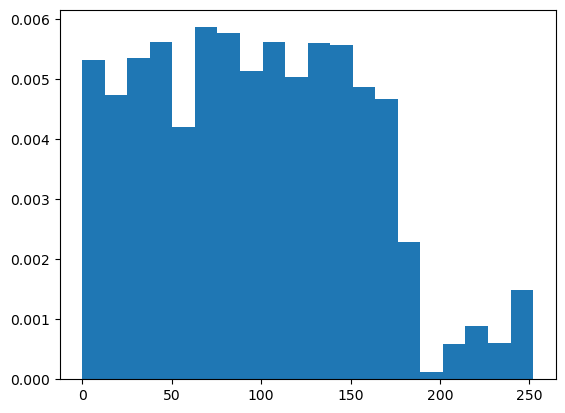

codebook utilization: 0.765625


In [18]:
plt.hist(codebook, density=True, bins=20)
plt.show()

cb_util = list(set(codebook))
cb_util = len(cb_util) / 256
print(f'codebook utilization: {cb_util}')

### Reconstructed particle features

In [19]:
#Return the particles' features of all the events in a batch
def extract_features(x, mask):
    
    eta_list = []
    phi_list = []
    pT_list = []

    for i in range(x.shape[0]):
        valid = x[i][mask[i]]
        for eta, phi, pT in valid:
            eta_list.append(eta)
            phi_list.append(phi)
            pT_list.append(pT)
    
    return eta_list, phi_list, pT_list

In [20]:
#Create the reconstructed feature lists 
eta_list = []
phi_list = []
pT_list = []

model_no_rot.eval()

for batch, mask in dataset_test:
    with torch.no_grad():
        output = model_no_rot.forward(batch, mask)
    
    feat = extract_features(output[0], mask)
    for i in range(len(feat[0])):
        eta_list.append(feat[0][i])
        phi_list.append(feat[1][i])
        pT_list.append(feat[2][i])


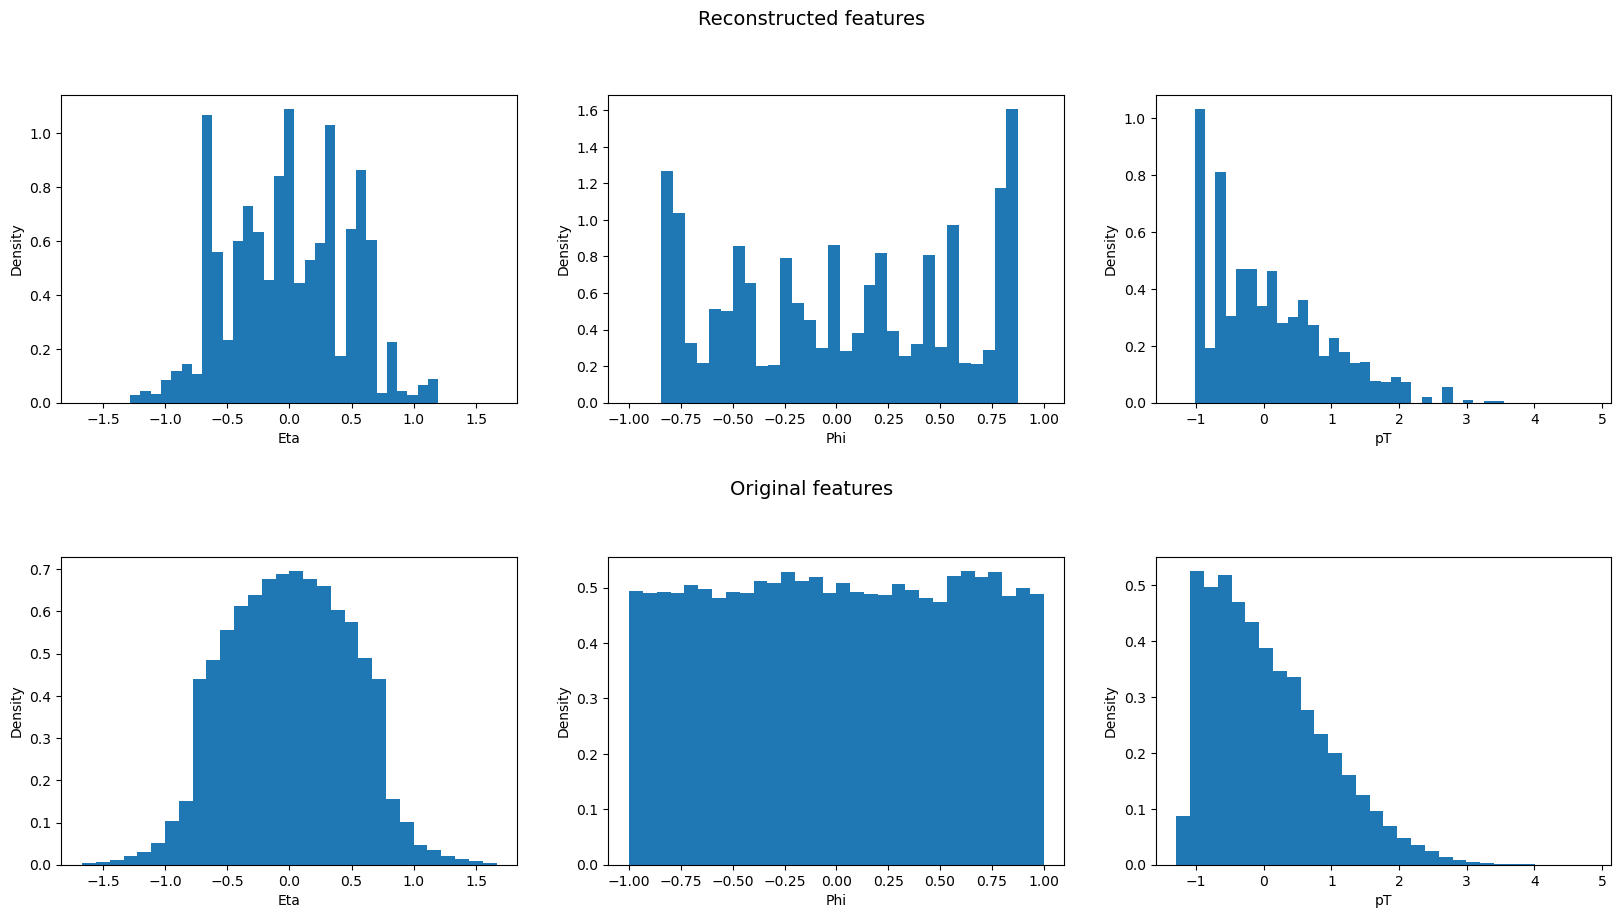

In [21]:
#Plot the reconstructed features and the original ones (preprocessed)
fig, ax = plt.subplots(2, 3, figsize=(20,10))

for i in range(3):
    ax[0, i].sharex(ax[1, i])

ax[0,0].hist(eta_list, density=True, bins=30)
ax[0,0].set_xlabel("Eta")
ax[0,0].set_ylabel("Density")

ax[0,1].hist(phi_list, density=True, bins=30)
ax[0,1].set_xlabel("Phi")
ax[0,1].set_ylabel("Density")

ax[0,2].hist(pT_list, density=True, bins=30)
ax[0,2].set_xlabel("pT")
ax[0,2].set_ylabel("Density")

fig.text(0.5, 0.95, "Reconstructed features", ha='center', fontsize=14)
fig.subplots_adjust(hspace=0.5)
fig.text(0.5, 0.48, "Original features", ha='center', fontsize=14)

ax[1,0].hist(eta_list_orig, density=True, bins=30)
ax[1,0].set_xlabel("Eta")
ax[1,0].set_ylabel("Density")

ax[1,1].hist(phi_list_orig, density=True, bins=30)
ax[1,1].set_xlabel("Phi")
ax[1,1].set_ylabel("Density")

ax[1,2].hist(pT_list_orig, density=True, bins=30)
ax[1,2].set_xlabel("pT")
ax[1,2].set_ylabel("Density")


plt.show()